In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/RETO_DS_AS.csv')
#data.head()
data.describe(include="all")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,9000.000000,9000,9000,9000,9000,9000.000000,9000,9000,9000,9000.000000,9000,9000.000000,9000.000000,9000.000000,9000.000000,9000,9000
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,1999,5124,4486,8865,NaN,4564,7820,6438,NaN,2361,NaN,NaN,NaN,NaN,6783,5213
mean,41.090556,NaN,NaN,NaN,NaN,1482.262778,NaN,NaN,NaN,15.619556,NaN,353.832778,2.520111,50.511333,0.788889,NaN,NaN
std,11.664253,NaN,NaN,NaN,NaN,3031.013197,NaN,NaN,NaN,8.345305,NaN,336.945158,2.737758,107.691963,2.210273,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-3058.000000,NaN,NaN,NaN,1.000000,NaN,3.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,32.000000,NaN,NaN,NaN,NaN,109.000000,NaN,NaN,NaN,8.000000,NaN,131.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,519.000000,NaN,NaN,NaN,15.000000,NaN,240.500000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1646.500000,NaN,NaN,NaN,21.000000,NaN,462.000000,3.000000,-1.000000,0.000000,NaN,NaN


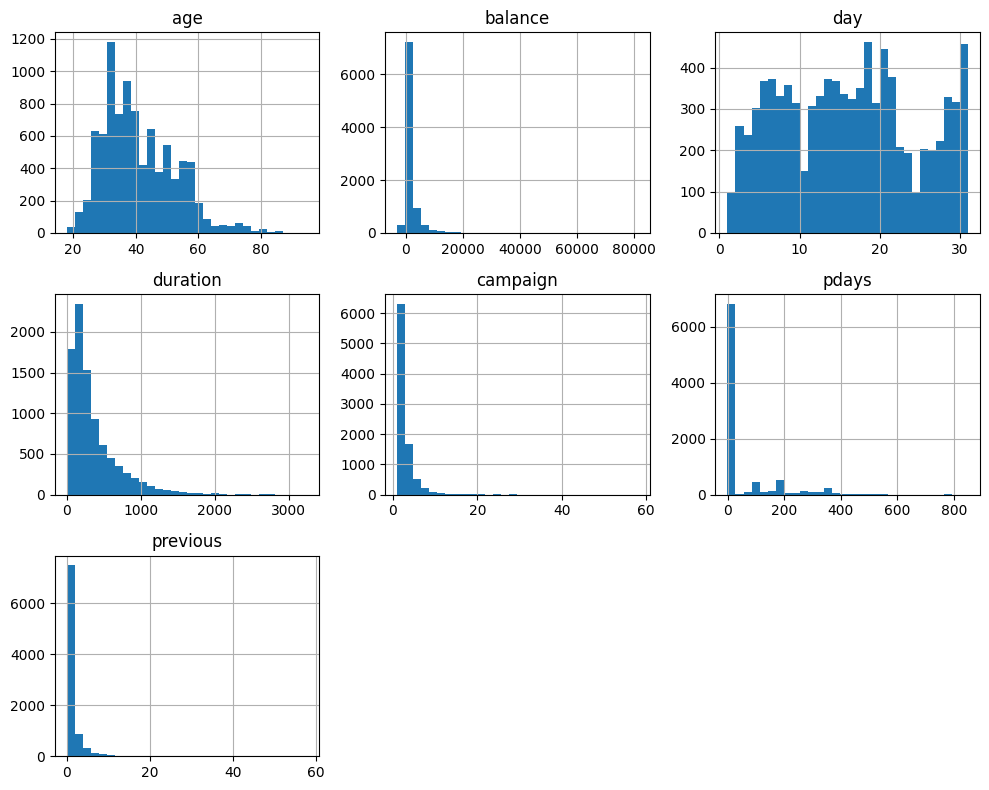

In [30]:
# VARIABLES DE ENTRADA (X) Y DE SALIDA (Y)

# X = matriz de factores / variables de entrada
X = data[['age','balance','day','duration','campaign','pdays','previous','job','marital','education','default','housing','loan','contact','month','poutcome']]

# Y = variable de clasificación de salida binaria
Y = data['y'].map({'no': 0, 'yes': 1})

# Convertir numpy
X = X.values
Y = Y.values

# variables de entrada
X = data.drop('y', axis=1)

numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
categorical_cols = [col for col in X.columns if col not in numeric_cols]

numeric_cols, categorical_cols

#vemos si las variables numéricas tienen mucho sesgo para ver si se aplica una transformacion log
X[numeric_cols].skew()
X[numeric_cols].hist(bins=30, figsize=(10,8))
plt.tight_layout()
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

#Entrenamiento (80%) test y validación 20%
x_train, x_validation_and_test, y_train, y_validation_and_test = train_test_split(X, Y, train_size=0.80, random_state=42, stratify=Y)

#split de validación
x_validation, x_test, y_validation, y_test = train_test_split(x_validation_and_test,y_validation_and_test,test_size=0.50,random_state=42,stratify=y_validation_and_test)

print("Entrenamiento:", x_train.shape)
print("Validación:",   x_validation.shape)
print("Prueba:",       x_test.shape)

Entrenamiento: (7200, 16)
Validación: (900, 16)
Prueba: (900, 16)


In [31]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

Probamos el modelo 1 de LR

In [32]:
#modelo 1
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_reg = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

log_reg.fit(x_train, y_train)

y_val_pred_lr = log_reg.predict(x_validation)

print("Accuracy validación (LR):", accuracy_score(y_validation, y_val_pred_lr))
print("Matriz de confusión (validación, LR):")
print(confusion_matrix(y_validation, y_val_pred_lr))
print(classification_report(y_validation, y_val_pred_lr))

Accuracy validación (LR): 0.8133333333333334
Matriz de confusión (validación, LR):
[[445  76]
 [ 92 287]]
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       521
           1       0.79      0.76      0.77       379

    accuracy                           0.81       900
   macro avg       0.81      0.81      0.81       900
weighted avg       0.81      0.81      0.81       900



Probamos el modelo 2 MLP

In [33]:
#modelo 2
mlp = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', MLPClassifier(hidden_layer_sizes=(20,10),
                            max_iter=500,
                            random_state=42))
])

mlp.fit(x_train, y_train)

y_val_pred_mlp = mlp.predict(x_validation)

print("Accuracy validación (MLP):", accuracy_score(y_validation, y_val_pred_mlp))
print("Matriz de confusión (validación, MLP):")
print(confusion_matrix(y_validation, y_val_pred_mlp))
print(classification_report(y_validation, y_val_pred_mlp))

Accuracy validación (MLP): 0.83
Matriz de confusión (validación, MLP):
[[418 103]
 [ 50 329]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.85       521
           1       0.76      0.87      0.81       379

    accuracy                           0.83       900
   macro avg       0.83      0.84      0.83       900
weighted avg       0.84      0.83      0.83       900



El mejor modelo es el MLP, con un 0.83 de accuracy vs 0.81 del LR. Usaremos la data de validación + training para hacer una corrida del modelo final.

In [35]:

X_train_final = pd.concat([x_train, x_validation])
y_train_final = np.concatenate([y_train, y_validation])


best_mlp = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', MLPClassifier(hidden_layer_sizes=(20, 10),max_iter=500,random_state=42))])


best_mlp.fit(X_train_final, y_train_final)
y_test_pred = best_mlp.predict(x_test)

print("Accuracy FINAL:", accuracy_score(y_test, y_test_pred))
print("\nMatriz de confusión (prueba):")
print(confusion_matrix(y_test, y_test_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_test_pred))


Accuracy FINAL: 0.8466666666666667

Matriz de confusión (prueba):
[[444  78]
 [ 60 318]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87       522
           1       0.80      0.84      0.82       378

    accuracy                           0.85       900
   macro avg       0.84      0.85      0.84       900
weighted avg       0.85      0.85      0.85       900



Terminamos con más accuracy en el modelo, con 0.85 aproximadamente.